In [ ]:
import os
os.chdir('/content/drive/MyDrive/Evaluation_dataset/')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

data_path = 'indianpinearray.npy'
gt_path = 'IPgt.npy'

data = np.load(data_path)
gt = np.load(gt_path)

print("Data shape:", data.shape)
print("Ground truth shape:", gt.shape)

Data shape: (145, 145, 200)
Ground truth shape: (145, 145)


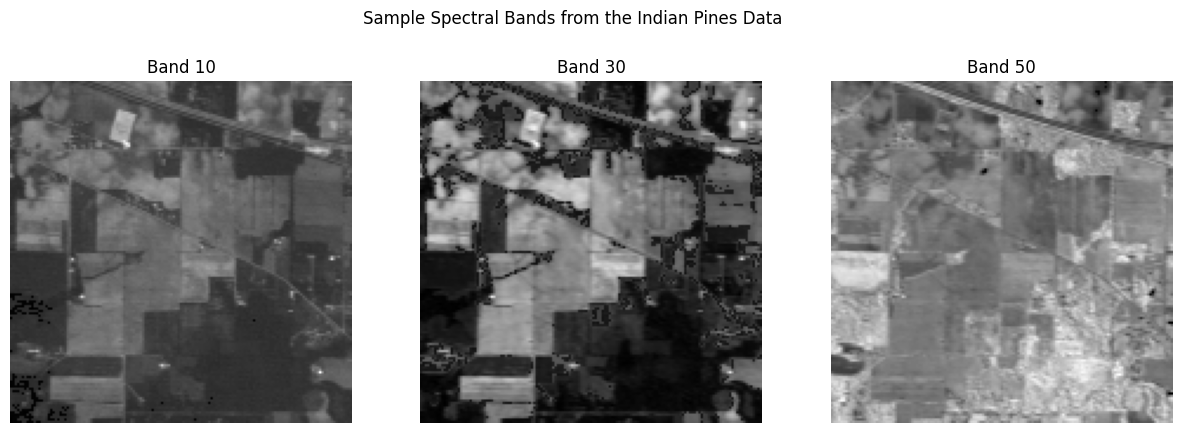

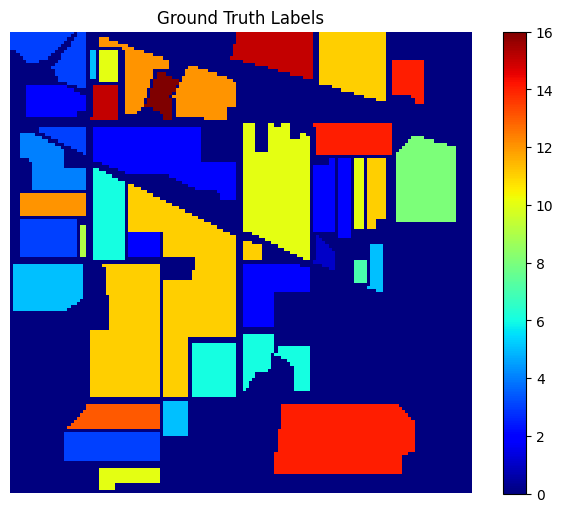

In [ ]:
bands_to_show = [10, 30, 50]

fig, axs = plt.subplots(1, len(bands_to_show), figsize=(15, 5))
for i, band in enumerate(bands_to_show):
    axs[i].imshow(data[:, :, band], cmap='gray')
    axs[i].set_title(f'Band {band}')
    axs[i].axis('off')
plt.suptitle("Sample Spectral Bands from the Indian Pines Data")
plt.show()

# Visualize the ground truth
plt.figure(figsize=(8, 6))
plt.imshow(gt, cmap='jet')
plt.title("Ground Truth Labels")
plt.colorbar()
plt.axis('off')
plt.show()

In [ ]:
def extract_patches(data, gt, patch_size=9):
    """
    Extract patches from the hyperspectral image.
    Only patches where the center pixel has a label > 0 are extracted.
    """
    margin = patch_size // 2
    padded_data = np.pad(data, ((margin, margin), (margin, margin), (0, 0)), mode='constant')
    patches = []
    labels = []
    for i in range(margin, padded_data.shape[0] - margin):
        for j in range(margin, padded_data.shape[1] - margin):
            # Use original ground truth (without padding)
            label = gt[i - margin, j - margin]
            if label > 0:  # consider only labeled pixels
                patch = padded_data[i - margin:i + margin + 1, j - margin:j + margin + 1, :]
                patches.append(patch)
                labels.append(label)
    return np.array(patches), np.array(labels)

# Extract patches
patch_size = 9  # You can experiment with patch sizes
patches, labels = extract_patches(data, gt, patch_size=patch_size)
print("Extracted patches shape:", patches.shape)
print("Labels shape:", labels.shape)


Extracted patches shape: (10249, 9, 9, 200)
Labels shape: (10249,)


## PyTorch Implementation

Now, let's port the model to PyTorch. We'll start by importing the necessary libraries and re-doing the data preprocessing to fit PyTorch's `Dataset` and `DataLoader` structure.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Preprocessing (manual implementation of scaling and label encoding) ---

# Reshape to 3D array for 1D CNN: (samples, sequence_length, features)
# patches is (N, patch_size, patch_size, bands) e.g., (10249, 9, 9, 200)
# We want (N, patch_size*patch_size, bands) e.g., (10249, 81, 200)
patches_reshaped = patches.reshape(patches.shape[0], -1, patches.shape[-1])

# Calculate mean and std for torchvision.transforms.Normalize
# These should be per-feature (per-band) statistics
# Calculate mean and std on the training data later, for now, use overall data for simplicity
# For a true split, these would be calculated on X_train_np only.
mean_values = np.mean(patches_reshaped, axis=(0, 1))
std_values = np.std(patches_reshaped, axis=(0, 1)) + 1e-8 # Add epsilon to avoid division by zero

# Manual Label Encoding
# Create a mapping from original labels to 0-indexed labels
unique_labels = np.unique(labels)
label_to_int = {label: i for i, label in enumerate(unique_labels)}
labels_encoded = np.array([label_to_int[label] for label in labels])
num_classes = len(unique_labels)

print("PyTorch Preprocessing Complete (before normalization by transform):")
print(f"Reshaped patches shape: {patches_reshaped.shape}")
print(f"Encoded labels shape: {labels_encoded.shape}")
print(f"Number of classes: {num_classes}")

# Train-test split (using numpy arrays before converting to PyTorch tensors)
# Manually stratify by creating indices for each class
def manual_train_test_split(X, y, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    unique_classes = np.unique(y)
    X_train, X_test, y_train, y_test = [], [], [], []

    for cls in unique_classes:
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)
        n_test = int(len(cls_indices) * test_size)

        X_train.append(X[cls_indices[n_test:]])
        y_train.append(y[cls_indices[n_test:]])
        X_test.append(X[cls_indices[:n_test]])
        y_test.append(y[cls_indices[:n_test]])

    X_train_np = np.concatenate(X_train)
    y_train_np = np.concatenate(y_train)
    X_test_np = np.concatenate(X_test)
    y_test_np = np.concatenate(y_test)

    # Shuffle the concatenated arrays to mix classes
    train_shuffle_idx = np.random.permutation(len(y_train_np))
    test_shuffle_idx = np.random.permutation(len(y_test_np))

    return X_train_np[train_shuffle_idx], X_test_np[test_shuffle_idx], \
           y_train_np[train_shuffle_idx], y_test_np[test_shuffle_idx]

X_train_np, X_test_np, y_train_np, y_test_np = manual_train_test_split(
    patches_reshaped, # Use unnormalized patches here
    labels_encoded,
    test_size=0.3,
    random_state=42
)

print(f"X_train_np shape: {X_train_np.shape}")
print(f"X_test_np shape: {X_test_np.shape}")
print(f"y_train_np shape: {y_train_np.shape}")
print(f"y_test_np shape: {y_test_np.shape}")

PyTorch Preprocessing Complete:
Normalized patches shape: (10249, 81, 200)
Encoded labels shape: (10249,)
Number of classes: 16
X_train_np shape: (7182, 81, 200)
X_test_np shape: (3067, 81, 200)
y_train_np shape: (7182,)
y_test_np shape: (3067,)


### Custom PyTorch Dataset

We'll create a `HyperspectralDataset` class to manage our preprocessed data patches and their corresponding labels. This class will inherit from PyTorch's `Dataset` and provide methods to get the length of the dataset and retrieve individual items (patch-label pairs).

In [ ]:
class HyperspectralDataset(Dataset):
    def __init__(self, X, y, transform=None):
        # Convert numpy arrays to PyTorch tensors
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long) # Use torch.long for classification labels
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        data = self.X[idx]
        label = self.y[idx]

        if self.transform:
            # torchvision.transforms.Normalize expects (C, H, W) or (C, L)
            # Our data is (sequence_length, features), so permute to (features, sequence_length)
            data = data.permute(1, 0)
            data = self.transform(data)
            data = data.permute(1, 0) # Permute back to (sequence_length, features) for the model

        return data, label

# Define the normalization transform using the calculated mean and std
normalize_transform = transforms.Normalize(mean=mean_values, std=std_values)

# Create Dataset instances
train_dataset = HyperspectralDataset(X_train_np, y_train_np, transform=normalize_transform)
test_dataset = HyperspectralDataset(X_test_np, y_test_np, transform=normalize_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 7182
Test dataset size: 3067


### PyTorch DataLoaders

Now, we'll create `DataLoader` instances for both the training and testing datasets. These will handle batching, shuffling, and loading data during the training process.

In [ ]:
batch_size = 256 # Keep the same batch size as the TF model

train_loader = DataLoader(train_dataset,\
                          batch_size=batch_size,\
                          shuffle=True,\
                          num_workers=True,\
                          pin_memory=True)
test_loader = DataLoader(test_dataset,\
                         batch_size=batch_size,\
                         shuffle=False,\
                         num_workers=True,\
                         pin_memory=True)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 29
Number of testing batches: 12


### PyTorch Model Definition

Next, let's define the 1D CNN model using `torch.nn.Module`. We'll replicate the architecture and regularizations used in the TensorFlow version.

In [ ]:
class CNN1DModel(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(CNN1DModel, self).__init__()
        # input_shape is (sequence_length, features) e.g., (81, 200)
        sequence_length, features = input_shape

        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels=features, out_channels=64, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3), # SpatialDropout1D equivalent after permute
            nn.MaxPool1d(kernel_size=2)
        )

        self.block2 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.MaxPool1d(kernel_size=2)
        )

        self.block3 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4)
        )

        # GlobalAveragePooling1D is equivalent to adaptive average pooling over the sequence_length
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(256, 256), # Output of global_pool is (batch_size, 256, 1) -> (batch_size, 256)
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        # L2 regularization is typically handled by the optimizer's weight_decay parameter
        # No need for explicit kernel_regularizer in the layers here.

    def forward(self, x):
        # PyTorch Conv1D expects (batch_size, in_channels, sequence_length)
        # Our input x is (batch_size, sequence_length, features), so we need to permute
        x = x.permute(0, 2, 1) # -> (batch_size, features, sequence_length)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.global_pool(x) # Output (batch_size, 256, 1)
        x = x.squeeze(-1) # Remove the last dimension -> (batch_size, 256)

        x = self.classifier(x)
        return x

# Instantiate the model
input_shape = (patches_reshaped.shape[1], patches_reshaped.shape[2]) # (sequence_length, features) = (81, 200)
model_pt = CNN1DModel(input_shape, num_classes)

print(model_pt)
print(f"Number of parameters: {sum(p.numel() for p in model_pt.parameters() if p.requires_grad)}")

CNN1DModel(
  (block1): Sequential(
    (0): Conv1d(200, 64, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=same)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Line

### Training Loop for PyTorch Model

Here we implement the full training loop, including:
-   **Optimizer**: Adam with L2 regularization (weight decay).
-   **Loss Function**: Cross-Entropy Loss, incorporating class weights.
-   **Learning Rate Scheduler**: Exponential decay.
-   **Early Stopping**: Monitoring validation loss to prevent overfitting.
-   **Class Weights**: Calculated from the training labels to handle class imbalance.

In [ ]:
# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pt.to(device)
print(f"Using device: {device}")

# Manual Class weights for imbalance
# Count occurrences of each class in y_train_np
class_counts = np.bincount(y_train_np)
# Inverse of the frequency, balanced by number of classes
total_samples = len(y_train_np)
class_weights_np = total_samples / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)


# Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer (L2 regularization handled by weight_decay)
optimizer = optim.Adam(model_pt.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning Rate Scheduler
lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

# Training parameters
epochs = 100
patience = 15 # For early stopping

# History tracking
history_pt = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Backpropagation
        optimizer.step() # Update weights

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train
    return train_loss, train_accuracy

def validate_one_epoch(model, test_loader, criterion, device):
    model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss /= len(test_loader.dataset)
    val_accuracy = correct_val / total_val
    return val_loss, val_accuracy

for epoch in range(epochs):
    train_loss, train_accuracy = train_one_epoch(model_pt, train_loader, optimizer, criterion, device)
    val_loss, val_accuracy = validate_one_epoch(model_pt, test_loader, criterion, device)

    # Store history
    history_pt['train_loss'].append(train_loss)
    history_pt['train_accuracy'].append(train_accuracy)
    history_pt['val_loss'].append(val_loss)
    history_pt['val_accuracy'].append(val_accuracy)
    history_pt['lr'].append(optimizer.param_groups[0]['lr'])

    print(f'Epoch {epoch+1}/{epochs}, '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}, '
          f'LR: {optimizer.param_groups[0]['lr']:.6f}')

    # Learning rate step
    lr_scheduler.step()

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_pt.state_dict(), 'best_model_pt.pth') # Save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {patience} epochs without improvement.')
            break

# Load best model weights for final evaluation
model_pt.load_state_dict(torch.load('best_model_pt.pth'))

# Final evaluation on test set
model_pt.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pt(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Manual accuracy calculation
final_test_accuracy = np.sum(np.array(all_labels) == np.array(all_preds)) / len(all_labels)
print(f"\nFinal PyTorch Test Accuracy: {final_test_accuracy * 100:.2f}%")

Using device: cuda
Epoch 1/100, Train Loss: 1.6488, Train Acc: 0.4607, Val Loss: 1.0273, Val Acc: 0.5406, LR: 0.001000
Epoch 2/100, Train Loss: 0.7439, Train Acc: 0.6615, Val Loss: 0.6282, Val Acc: 0.6792, LR: 0.000950
Epoch 3/100, Train Loss: 0.4438, Train Acc: 0.7717, Val Loss: 0.9443, Val Acc: 0.5432, LR: 0.000902
Epoch 4/100, Train Loss: 0.3430, Train Acc: 0.8177, Val Loss: 0.4872, Val Acc: 0.6991, LR: 0.000857
Epoch 5/100, Train Loss: 0.2776, Train Acc: 0.8390, Val Loss: 0.4348, Val Acc: 0.6808, LR: 0.000815
Epoch 6/100, Train Loss: 0.2011, Train Acc: 0.8797, Val Loss: 0.4740, Val Acc: 0.7571, LR: 0.000774
Epoch 7/100, Train Loss: 0.2364, Train Acc: 0.8693, Val Loss: 0.7752, Val Acc: 0.5641, LR: 0.000735
Epoch 8/100, Train Loss: 0.2748, Train Acc: 0.8590, Val Loss: 0.6382, Val Acc: 0.5840, LR: 0.000698
Epoch 9/100, Train Loss: 0.1891, Train Acc: 0.9000, Val Loss: 0.2946, Val Acc: 0.7848, LR: 0.000663
Epoch 10/100, Train Loss: 0.1467, Train Acc: 0.9142, Val Loss: 0.2709, Val Acc: 0

### Visualize Training History and Evaluation Metrics (PyTorch)

We'll now plot the training and validation accuracy/loss curves for the PyTorch model and generate a confusion matrix and classification report.

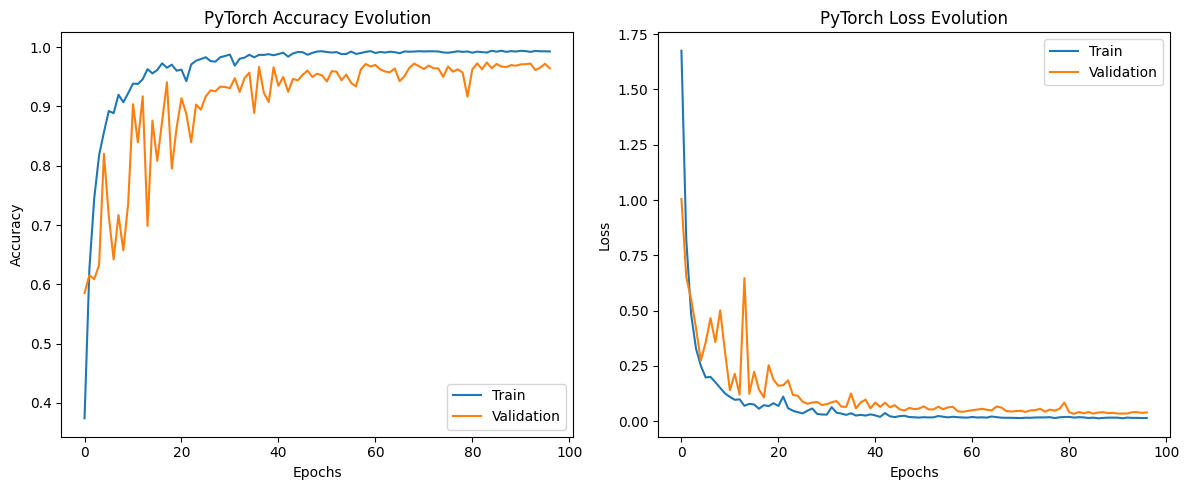

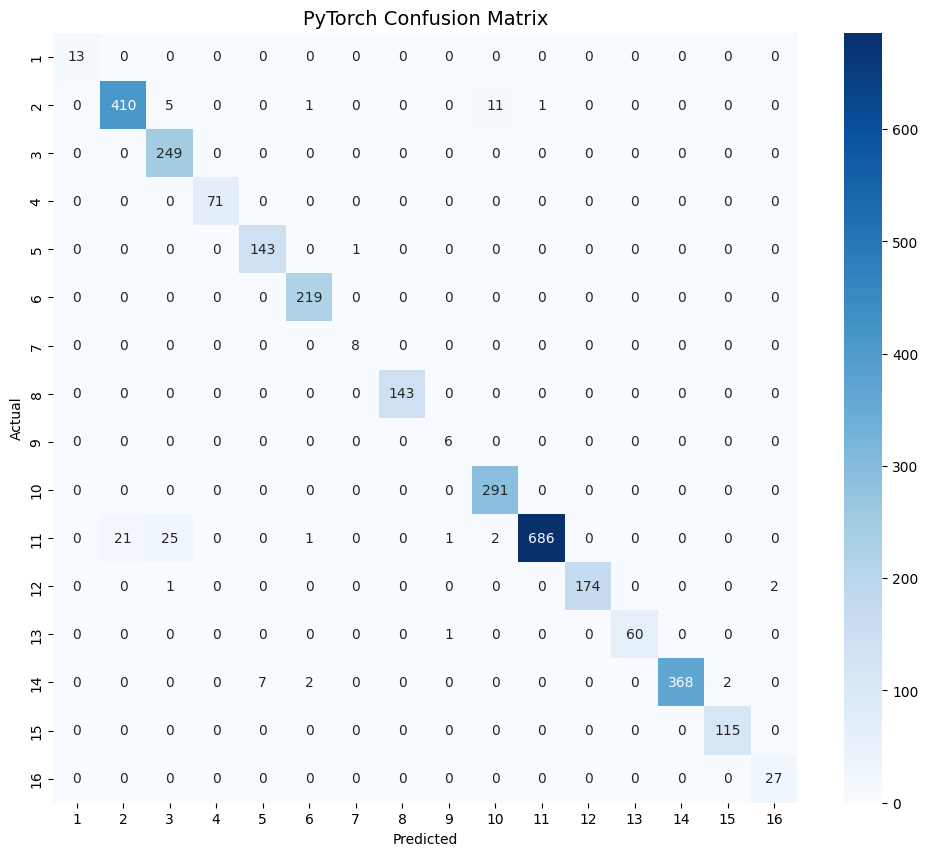


PyTorch Extended Classification Report:
            precision     recall   f1-score    support
--------------------------------------------------
         1     1.0000     1.0000     1.0000         13
         2     0.9513     0.9579     0.9546        428
         3     0.8893     1.0000     0.9414        249
         4     1.0000     1.0000     1.0000         71
         5     0.9533     0.9931     0.9728        144
         6     0.9821     1.0000     0.9910        219
         7     0.8889     1.0000     0.9412          8
         8     1.0000     1.0000     1.0000        143
         9     0.7500     1.0000     0.8571          6
        10     0.9572     1.0000     0.9782        291
        11     0.9985     0.9321     0.9642        736
        12     1.0000     0.9831     0.9915        177
        13     1.0000     0.9836     0.9917         61
        14     1.0000     0.9710     0.9853        379
        15     0.9829     1.0000     0.9914        115
        16     0.9310     1.

In [ ]:
# Function to plot history (adapted for PyTorch history_pt dictionary)
def plot_pytorch_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_accuracy'], label='Train')
    plt.plot(history['val_accuracy'], label='Validation')
    plt.title('PyTorch Accuracy Evolution')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title('PyTorch Loss Evolution')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_pytorch_history(history_pt)

# 2. Manual Confusion Matrix and Classification Report
# Use the `unique_labels` and `label_to_int` from preprocessing if available,
# otherwise derive from all_labels and all_preds.
# Assuming 'unique_labels' is still in scope from previous cell

class_names = [str(label) for label in unique_labels] # Use original labels for names

# Manual Confusion Matrix
cm_pt = np.zeros((num_classes, num_classes), dtype=int)
for true, pred in zip(all_labels, all_preds):
    cm_pt[true, pred] += 1

plt.figure(figsize=(12,10))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('PyTorch Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nPyTorch Extended Classification Report:")
# Manual Classification Report
def manual_classification_report(y_true, y_pred, target_names, digits=4):
    report = []
    header = f"{'':>10} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    report.append(header)
    report.append(f"{'':->50}")

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    all_precision, all_recall, all_f1, all_support = [], [], [], []

    for i, name in enumerate(target_names):
        true_pos = np.sum((y_true == i) & (y_pred == i))
        false_pos = np.sum((y_true != i) & (y_pred == i))
        false_neg = np.sum((y_true == i) & (y_pred != i))
        support = np.sum(y_true == i)

        precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
        recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        all_precision.append(precision)
        all_recall.append(recall)
        all_f1.append(f1_score)
        all_support.append(support)

        report.append(f"{name:>10} {precision:>10.{digits}f} {recall:>10.{digits}f} {f1_score:>10.{digits}f} {support:>10}")

    report.append(f"{'':->50}")

    # Calculate totals and averages
    total_support = np.sum(all_support)
    macro_precision = np.mean(all_precision)
    macro_recall = np.mean(all_recall)
    macro_f1 = np.mean(all_f1)

    # Weighted average
    weighted_precision = np.sum(np.array(all_precision) * np.array(all_support)) / total_support
    weighted_recall = np.sum(np.array(all_recall) * np.array(all_support)) / total_support
    weighted_f1 = np.sum(np.array(all_f1) * np.array(all_support)) / total_support

    accuracy = np.sum(y_true == y_pred) / len(y_true)

    report.append(f"\n{'accuracy':>10} {'':>10} {'':>10} {accuracy:>10.{digits}f} {total_support:>10}")
    report.append(f"{'macro avg':>10} {macro_precision:>10.{digits}f} {macro_recall:>10.{digits}f} {macro_f1:>10.{digits}f} {total_support:>10}")
    report.append(f"{'weighted avg':>10} {weighted_precision:>10.{digits}f} {weighted_recall:>10.{digits}f} {weighted_f1:>10.{digits}f} {total_support:>10}")

    return "\n".join(report)

print(manual_classification_report(all_labels, all_preds, target_names=class_names, digits=4))

print("\nPyTorch Performance Summary ")
print(f"Best Training Accuracy: {max(history_pt['train_accuracy']):.2%}")
print(f"Best Validation Accuracy: {max(history_pt['val_accuracy']):.2%}")
print(f"Final Test Accuracy: {final_test_accuracy:.2%}")
print(f"Minimum Validation Loss: {min(history_pt['val_loss']):.4f}")